In [18]:
!pip install -q transformers librosa wandb
!git clone https://github.com/Rudrabha/Wav2Lip.git 2>/dev/null || true
!mkdir -p Wav2Lip/checkpoints

!wget -q -nc "https://huggingface.co/Nekochu/Wav2Lip/resolve/main/wav2lip.pth" -O Wav2Lip/checkpoints/wav2lip.pth
!wget -q -nc "https://huggingface.co/Nekochu/Wav2Lip/resolve/main/lipsync_expert.pth" -O Wav2Lip/checkpoints/lipsync_expert.pth
!ls -lh Wav2Lip/checkpoints/*.pth

-rw-r--r-- 1 root root 189M Mar  8 07:00 Wav2Lip/checkpoints/lipsync_expert.pth
-rw-r--r-- 1 root root 416M Mar  8 07:00 Wav2Lip/checkpoints/wav2lip.pth


In [19]:
import sys
sys.path.insert(0, "/content")
sys.path.insert(0, "/content/Wav2Lip")

import gc
import json
import warnings
from pathlib import Path

import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import wandb
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from emotion_utils import (
    CrossModalEmotionLoss as _CrossModalEmotionLoss,
    DifferentiableVideoPreprocess,
    EmotionAgreementMetric,
    load_frozen_audio_encoder,
    load_frozen_video_encoder,
    extract_audio_embedding,
    extract_video_embedding,
)
from models.wav2lip import Wav2Lip as Wav2LipModel


class CrossModalEmotionLoss(nn.Module):
    """F.normalize removed — redundant before F.cosine_similarity."""
    def __init__(self, weight=1.0):
        super().__init__()
        self.weight = weight

    def forward(self, audio_emb, video_emb):
        return self.weight * (1.0 - F.cosine_similarity(audio_emb, video_emb, dim=-1)).mean()

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
METADATA = "/content/processed_data/metadata.json"
WAV2LIP_CKPT = "/content/Wav2Lip/checkpoints/wav2lip.pth"
BEST_AUDIO_PATH = "/content/trained_encoders/w2v2-lg-lr2e5"
BEST_VIDEO_PATH = "/content/trained_encoders/tsf-lr3e5-16f-nf"
OUT_DIR = Path("/content/wav2lip_finetuned")
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE = {0, 1, 3, 5, 7}
REMAP = {2: 0, 4: 1, 6: 2}
EMOTIONS = ["happy", "angry", "disgust"]
WAV2LIP_TO_ENCODER = [1, 3, 5]  # wav2lip label → encoder class: happy→1, angry→3, disgust→5

print(f"Device: {DEVICE}")

Device: cuda


In [20]:
IMG_SIZE = 96
MEL_STEP = 16
SR = 16000
FPS = 25

def wav_to_mel(wav_path, sr=SR):
    y, _ = librosa.load(wav_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=80, hop_length=200, win_length=800,
        fmin=55, fmax=7600)
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)


class Wav2LipDataset(Dataset):
    def __init__(self, metadata_path, split, T=5):
        with open(metadata_path) as f:
            data = json.load(f)
        self.samples = [s for s in data
                        if s["split"] == split and s["emotion_idx"] not in EXCLUDE]
        self.T = T

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        wav, sr = torchaudio.load(s["audio_path"])
        audio_1d = wav.squeeze(0)

        mel = wav_to_mel(s["audio_path"])

        frames = np.load(s["frames_path"]).astype(np.float32) / 255.0
        n_frames = frames.shape[0]

        start = np.random.randint(0, max(1, n_frames - self.T))
        face_window = frames[start:start + self.T]
        if face_window.shape[0] < self.T:
            pad = np.repeat(face_window[-1:], self.T - face_window.shape[0], axis=0)
            face_window = np.concatenate([face_window, pad], axis=0)

        mel_start = int(start / FPS * SR / 200)
        mel_end = mel_start + MEL_STEP * self.T
        mel_window = mel[:, mel_start:mel_end]
        if mel_window.shape[1] < MEL_STEP * self.T:
            mel_window = np.pad(mel_window, ((0, 0), (0, MEL_STEP * self.T - mel_window.shape[1])))

        gt = torch.from_numpy(face_window).permute(0, 3, 1, 2)
        H, W = gt.shape[2], gt.shape[3]
        if H != IMG_SIZE or W != IMG_SIZE:
            gt = F.interpolate(gt, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

        masked = gt.clone()
        masked[:, :, IMG_SIZE // 2:, :] = 0.0

        ref_idx = np.random.randint(0, n_frames)
        ref = torch.from_numpy(frames[ref_idx]).permute(2, 0, 1).unsqueeze(0).expand(self.T, -1, -1, -1)
        if ref.shape[2] != IMG_SIZE or ref.shape[3] != IMG_SIZE:
            ref = F.interpolate(ref, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

        face_input = torch.cat([ref, masked], dim=1)

        mel_chunks = []
        for t in range(self.T):
            m = mel_window[:, t * MEL_STEP:(t + 1) * MEL_STEP]
            mel_chunks.append(torch.from_numpy(m).unsqueeze(0))
        mel_tensor = torch.stack(mel_chunks, dim=0)

        return {
            "mel": mel_tensor,
            "face_input": face_input,
            "gt": gt,
            "audio": audio_1d,
            "emotion": REMAP[s["emotion_idx"]],
        }


def collate_wav2lip(batch):
    return {
        "mel": torch.stack([b["mel"] for b in batch]),
        "face_input": torch.stack([b["face_input"] for b in batch]),
        "gt": torch.stack([b["gt"] for b in batch]),
        "audio": [b["audio"] for b in batch],
        "emotion": torch.tensor([b["emotion"] for b in batch]),
    }

In [21]:
def load_wav2lip(ckpt_path, device, freeze_encoders=True):
    model = Wav2LipModel()
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    state = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    state = {k.replace("module.", ""): v for k, v in state.items()}
    model.load_state_dict(state, strict=False)
    if freeze_encoders:
        for p in model.face_encoder_blocks.parameters():
            p.requires_grad = False
        for p in model.audio_encoder.parameters():
            p.requires_grad = False
    return model.to(device)

wav2lip = load_wav2lip(WAV2LIP_CKPT, DEVICE)
total_params = sum(p.numel() for p in wav2lip.parameters())
trainable_params = sum(p.numel() for p in wav2lip.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params
print(f"Wav2Lip: {total_params/1e6:.1f}M total, {trainable_params/1e6:.1f}M trainable, {frozen_params/1e6:.1f}M frozen")

audio_enc, audio_proc = load_frozen_audio_encoder(BEST_AUDIO_PATH, DEVICE)
video_enc = load_frozen_video_encoder(BEST_VIDEO_PATH, DEVICE)
video_preprocess = DifferentiableVideoPreprocess(224).to(DEVICE)

VIDEO_ENC_FRAMES = getattr(video_enc.config, "num_frames", 8)
AUDIO_DIM = audio_enc.config.hidden_size
VIDEO_DIM = video_enc.config.hidden_size
PROJ_DIM = 256
print(f"Frozen encoders loaded. Video: {VIDEO_ENC_FRAMES} frames. "
      f"Audio dim={AUDIO_DIM}, Video dim={VIDEO_DIM}, Proj dim={PROJ_DIM}")

Wav2Lip: 36.3M total, 25.3M trainable, 11.0M frozen
Frozen encoders loaded. Video: 8 frames. Audio dim=1024, Video dim=768, Proj dim=256


In [22]:
wandb.login()

CONFIGS = [
    {"name": "wav2lip-baseline", "lambda_emo": 0.0},
    {"name": "wav2lip-emo-001",  "lambda_emo": 0.01},
    {"name": "wav2lip-emo-002",  "lambda_emo": 0.02},
    {"name": "wav2lip-emo-003",  "lambda_emo": 0.03},
    {"name": "wav2lip-emo-004",  "lambda_emo": 0.04},
    {"name": "wav2lip-emo-005",  "lambda_emo": 0.05},
    {"name": "wav2lip-emo-01",   "lambda_emo": 0.1},
]

LR = 1e-4
EPOCHS = 70
BATCH_SIZE = 16
PATIENCE = 5
T_FRAMES = 5
NUM_WORKERS = 2

wandb: Currently logged in as: katrinpochtar to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [23]:
def adapt_frames(frames, target_t):
    """Resample (B, T, C, H, W) to (B, target_t, C, H, W) via uniform index sampling."""
    B, T, C, H, W = frames.shape
    if T == target_t:
        return frames
    idx = torch.linspace(0, T - 1, target_t).long()
    return frames[:, idx]


def classify_gen_video(gen_frames, batch_emotions):
    """Run generated video through the frozen video emotion classifier.
    Returns 3-class logits (happy/angry/disgust) and 3-class labels (0/1/2)."""
    gen_video = adapt_frames(gen_frames, VIDEO_ENC_FRAMES)
    pv = video_preprocess(gen_video)
    logits_6 = video_enc(pixel_values=pv).logits
    logits_3 = logits_6[:, WAV2LIP_TO_ENCODER]
    labels_3 = batch_emotions.to(DEVICE)
    return logits_3, labels_3


def train_one_epoch(model, loader, optimizer, scaler, lambda_emo):
    model.train()
    total_recon, total_emo, total_loss = 0.0, 0.0, 0.0

    for batch in tqdm(loader, leave=False):
        mel = batch["mel"].to(DEVICE)
        face_in = batch["face_input"].to(DEVICE)
        gt = batch["gt"].to(DEVICE)
        B, T = mel.shape[0], mel.shape[1]

        optimizer.zero_grad(set_to_none=True)

        all_gen = []
        recon = 0.0
        with autocast("cuda", enabled=DEVICE == "cuda"):
            for t in range(T):
                gen = model(mel[:, t], face_in[:, t])
                recon += F.l1_loss(gen, gt[:, t])
                all_gen.append(gen)
            recon = recon / T

            emo = torch.tensor(0.0, device=DEVICE)
            if lambda_emo > 0:
                gen_video = torch.stack(all_gen, dim=1)
                logits, enc_labels = classify_gen_video(gen_video, batch["emotion"])
                emo = F.cross_entropy(logits, enc_labels)

            loss = recon + lambda_emo * emo

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_recon += recon.item()
        total_emo += emo.item()
        total_loss += loss.item()

    n = len(loader)
    return {"recon": total_recon / n, "emotion": total_emo / n, "total": total_loss / n}


@torch.no_grad()
def evaluate(model, loader, lambda_emo):
    """Always computes emotion classification accuracy as an independent metric."""
    model.eval()
    total_recon, total_emo, total_loss = 0.0, 0.0, 0.0
    correct, total_samples = 0, 0

    for batch in tqdm(loader, leave=False):
        mel = batch["mel"].to(DEVICE)
        face_in = batch["face_input"].to(DEVICE)
        gt = batch["gt"].to(DEVICE)
        B, T = mel.shape[0], mel.shape[1]

        all_gen = []
        recon = 0.0
        with autocast("cuda", enabled=DEVICE == "cuda"):
            for t in range(T):
                gen = model(mel[:, t], face_in[:, t])
                recon += F.l1_loss(gen, gt[:, t])
                all_gen.append(gen)
            recon = recon / T

            gen_video = torch.stack(all_gen, dim=1)
            logits, enc_labels = classify_gen_video(gen_video, batch["emotion"])

            emo = F.cross_entropy(logits, enc_labels) if lambda_emo > 0 else torch.tensor(0.0, device=DEVICE)
            loss = recon + lambda_emo * emo

            preds = logits.argmax(dim=1)
            correct += (preds == enc_labels).sum().item()
            total_samples += enc_labels.shape[0]

        total_recon += recon.item()
        total_emo += emo.item()
        total_loss += loss.item()

    n = len(loader)
    return {
        "recon": total_recon / n,
        "emotion": total_emo / n,
        "total": total_loss / n,
        "emo_accuracy": correct / total_samples if total_samples > 0 else 0,
    }

In [24]:
train_ds = Wav2LipDataset(METADATA, "train", T=T_FRAMES)
val_ds = Wav2LipDataset(METADATA, "val", T=T_FRAMES)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_wav2lip)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True,
                        collate_fn=collate_wav2lip)
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

all_results = []

for cfg in CONFIGS:
    name = cfg["name"]
    lambda_emo = cfg["lambda_emo"]
    print(f"\n{'='*60}\n{name} (lambda_emo={lambda_emo})\n{'='*60}")

    wandb.init(project="uncanny-valley-wav2lip", name=name,
               config={**cfg, "lr": LR, "epochs": EPOCHS}, reinit=True)

    model = load_wav2lip(WAV2LIP_CKPT, DEVICE, freeze_encoders=True)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    scaler = GradScaler(enabled=DEVICE == "cuda")

    best_val, patience_cnt = float("inf"), 0
    save_path = OUT_DIR / name

    for epoch in range(EPOCHS):
        t = train_one_epoch(model, train_loader, optimizer, scaler, lambda_emo)
        v = evaluate(model, val_loader, lambda_emo)

        wandb.log({
            "epoch": epoch + 1,
            "train/recon": t["recon"], "train/emotion": t["emotion"], "train/total": t["total"],
            "val/recon": v["recon"], "val/emotion": v["emotion"], "val/total": v["total"],
            "val/emo_accuracy": v["emo_accuracy"],
        })

        print(f"  [{epoch+1:2d}/{EPOCHS}] "
              f"t_loss={t['total']:.4f} v_loss={v['total']:.4f} v_recon={v['recon']:.4f}"
              f" emo_acc={v['emo_accuracy']:.3f}")

        if v["total"] < best_val:
            best_val = v["total"]
            save_path.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), save_path / "wav2lip.pth")
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    wandb.finish()
    del model, optimizer, scaler
    torch.cuda.empty_cache()
    gc.collect()
    all_results.append({"name": name, "lambda_emo": lambda_emo, "best_val": best_val})
    print(f"  Best val loss: {best_val:.4f} -> {save_path}")

Train: 408, Val: 72

wav2lip-baseline (lambda_emo=0.0)


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [ 1/70] t_loss=0.4015 v_loss=0.3933 v_recon=0.3933 emo_acc=0.361


  [ 2/70] t_loss=0.3829 v_loss=0.3701 v_recon=0.3701 emo_acc=0.375


  [ 3/70] t_loss=0.3698 v_loss=0.3582 v_recon=0.3582 emo_acc=0.319


...

  [63/70] t_loss=0.1384 v_loss=0.1673 v_recon=0.1076 emo_acc=0.736


  [64/70] t_loss=0.1471 v_loss=0.1641 v_recon=0.1081 emo_acc=0.736


  [65/70] t_loss=0.1462 v_loss=0.1738 v_recon=0.1108 emo_acc=0.736
  Early stopping at epoch 65


epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train/emotion,████▇▇▇▇▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▂▂▂▁▁▂▁▂
train/recon,██▇▇▇▆▆▆▆▆▅▅▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train/total,██▇▇▇▆▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/emo_accuracy,▁▁▁▁▂▃▄▅▁▅▅▆▄▅▇▆▇▇▆▇▇▇▇▆▇▇▆▆█▆▇▆▇▅▆▅▇▇▅▆
val/emotion,█▆▆▆▆▆▅▄▄▆▃▃▃▂▃▃▄▃▁▂▃▁▁▁▂▂▃▂▃▃▁▄▁▂▃▃▂▂▂▃
val/recon,███▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▄▃▂▃▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁
val/total,██▇▇▇▇▆▆▅▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁
epoch,65
train/emotion,0.39273
train/recon,0.10695


  Best val loss: 0.1527 -> /content/wav2lip_finetuned/wav2lip-emo-01


            name  lambda_emo  best_val
wav2lip-baseline        0.00  0.051483
 wav2lip-emo-001        0.01  0.070261
 wav2lip-emo-002        0.02  0.081873
 wav2lip-emo-003        0.03  0.084976
 wav2lip-emo-004        0.04  0.095152
 wav2lip-emo-005        0.05  0.114499
  wav2lip-emo-01        0.10  0.152706


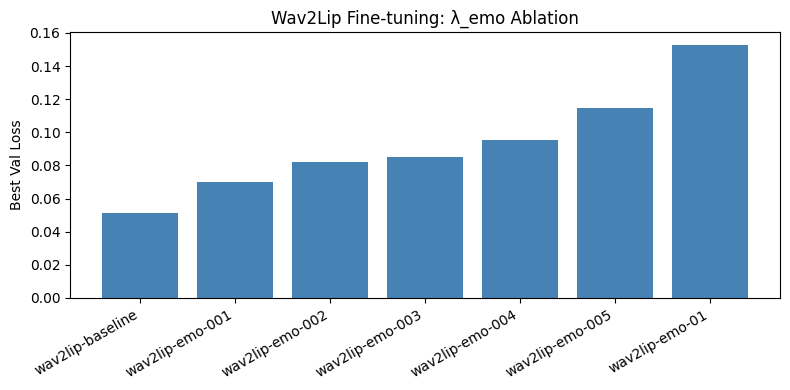

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(all_results).sort_values("best_val")
print(df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df["name"], df["best_val"], color="steelblue")
ax.set_ylabel("Best Val Loss")
ax.set_title("Wav2Lip Fine-tuning: λ_emo Ablation")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [26]:
best_name = df.iloc[0]["name"]
best_model = load_wav2lip(WAV2LIP_CKPT, DEVICE)
best_model.load_state_dict(torch.load(OUT_DIR / best_name / "wav2lip.pth", map_location=DEVICE, weights_only=True))
best_model.eval()
print(f"Loaded best model: {best_name}")

all_recon = []
correct, total_samples = 0, 0

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating best"):
        mel = batch["mel"].to(DEVICE)
        face_in = batch["face_input"].to(DEVICE)
        gt = batch["gt"].to(DEVICE)
        T = mel.shape[1]

        all_gen = []
        for t in range(T):
            gen = best_model(mel[:, t], face_in[:, t])
            all_gen.append(gen)
            all_recon.append(F.l1_loss(gen, gt[:, t]).item())

        gen_video = torch.stack(all_gen, dim=1)
        logits, enc_labels = classify_gen_video(gen_video, batch["emotion"])
        preds = logits.argmax(dim=1)
        correct += (preds == enc_labels).sum().item()
        total_samples += enc_labels.shape[0]

emo_acc = correct / total_samples if total_samples > 0 else 0
print(f"\nBest model evaluation:")
print(f"  Avg L1 recon:       {np.mean(all_recon):.4f}")
print(f"  Emotion accuracy:   {emo_acc:.4f}")

del best_model
torch.cuda.empty_cache()

Loaded best model: wav2lip-baseline


Evaluating best: 100%|██████████| 5/5 [00:05<00:00,  1.06s/it]


Best model evaluation:
  Avg L1 recon:       0.0533
  Emotion accuracy:   0.5694


Evaluating baseline (L1 only)...


Evaluating best (L1 + emotion loss)...



=== Baseline vs Best comparison ===
      metric  wav2lip-baseline  wav2lip-emo-001    delta
    L1 recon          0.051601         0.068924 0.017323
emo_accuracy          0.555556         0.736111 0.180556

=== Per-emotion classification accuracy ===
emotion  wav2lip-baseline_acc  wav2lip-emo-001_acc    delta
  happy              0.708333             0.916667 0.208333
  angry              0.375000             0.625000 0.250000
disgust              0.583333             0.666667 0.083333


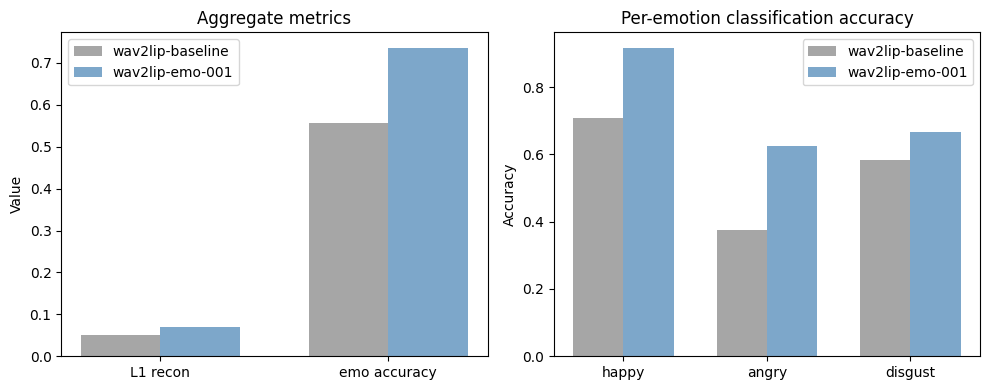


=== Side-by-side sample frames (one per emotion) ===


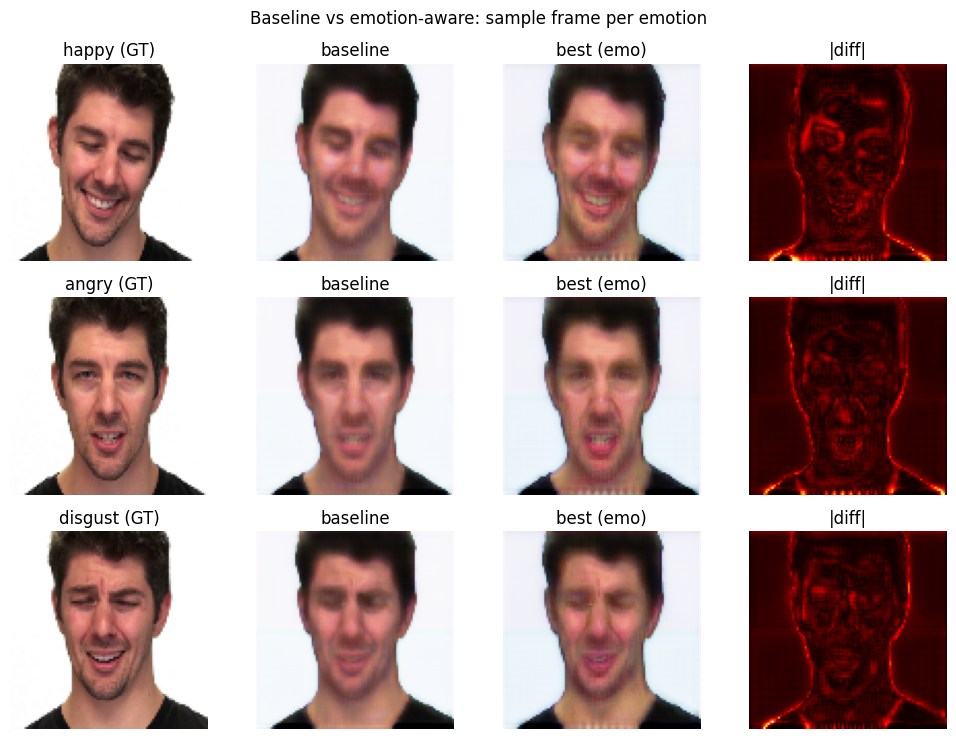

In [27]:
"""Baseline vs Best: emotion classification accuracy on generated videos"""

baseline_name = "wav2lip-baseline"
best_name = "wav2lip-emo-001"

ENC_CLASS_TO_LABEL = {v: i for i, v in enumerate(WAV2LIP_TO_ENCODER)}

def eval_model(model, loader):
    """Evaluate model with L1 recon and emotion classification accuracy."""
    model.eval()
    recon_list = []
    correct_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    total_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    with torch.no_grad():
        for batch in tqdm(loader, leave=False, desc="Eval"):
            mel = batch["mel"].to(DEVICE)
            face_in = batch["face_input"].to(DEVICE)
            gt = batch["gt"].to(DEVICE)
            T = mel.shape[1]
            all_gen = []
            for t in range(T):
                gen = model(mel[:, t], face_in[:, t])
                all_gen.append(gen)
                recon_list.append(F.l1_loss(gen, gt[:, t]).item())
            gen_video = torch.stack(all_gen, dim=1)
            logits, enc_labels = classify_gen_video(gen_video, batch["emotion"])
            preds = logits.argmax(dim=1)
            for i, e in enumerate(batch["emotion"].tolist()):
                total_by_emo[e] += 1
                if preds[i].item() == enc_labels[i].item():
                    correct_by_emo[e] += 1
    total_correct = sum(correct_by_emo.values())
    total_samples = sum(total_by_emo.values())
    return {
        "recon": np.mean(recon_list),
        "emo_accuracy": total_correct / total_samples if total_samples > 0 else 0,
        "by_emotion": {
            e: correct_by_emo[e] / total_by_emo[e] if total_by_emo[e] > 0 else 0
            for e in range(len(EMOTIONS))
        },
    }

baseline = load_wav2lip(WAV2LIP_CKPT, DEVICE)
baseline.load_state_dict(torch.load(OUT_DIR / baseline_name / "wav2lip.pth", map_location=DEVICE, weights_only=True))

best = load_wav2lip(WAV2LIP_CKPT, DEVICE)
best.load_state_dict(torch.load(OUT_DIR / best_name / "wav2lip.pth", map_location=DEVICE, weights_only=True))

print("Evaluating baseline (L1 only)...")
baseline_metrics = eval_model(baseline, val_loader)
print("Evaluating best (L1 + emotion loss)...")
best_metrics = eval_model(best, val_loader)

cmp = pd.DataFrame({
    "metric": ["L1 recon", "emo_accuracy"],
    baseline_name: [baseline_metrics["recon"], baseline_metrics["emo_accuracy"]],
    best_name: [best_metrics["recon"], best_metrics["emo_accuracy"]],
})
cmp["delta"] = cmp[best_name] - cmp[baseline_name]
print("\n=== Baseline vs Best comparison ===")
print(cmp.to_string(index=False))

per_emo = pd.DataFrame({
    "emotion": EMOTIONS,
    f"{baseline_name}_acc": [baseline_metrics["by_emotion"][e] for e in range(len(EMOTIONS))],
    f"{best_name}_acc": [best_metrics["by_emotion"][e] for e in range(len(EMOTIONS))],
})
per_emo["delta"] = per_emo[f"{best_name}_acc"] - per_emo[f"{baseline_name}_acc"]
print("\n=== Per-emotion classification accuracy ===")
print(per_emo.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x_agg = np.arange(2)
w_agg = 0.35
axes[0].bar(x_agg - w_agg/2, [baseline_metrics["recon"], baseline_metrics["emo_accuracy"]], w_agg, label=baseline_name, color="gray", alpha=0.7)
axes[0].bar(x_agg + w_agg/2, [best_metrics["recon"], best_metrics["emo_accuracy"]], w_agg, label=best_name, color="steelblue", alpha=0.7)
axes[0].set_xticks(x_agg)
axes[0].set_xticklabels(["L1 recon", "emo accuracy"])
axes[0].set_ylabel("Value")
axes[0].legend()
axes[0].set_title("Aggregate metrics")

x = np.arange(len(EMOTIONS))
w = 0.35
axes[1].bar(x - w/2, per_emo[f"{baseline_name}_acc"], w, label=baseline_name, color="gray", alpha=0.7)
axes[1].bar(x + w/2, per_emo[f"{best_name}_acc"], w, label=best_name, color="steelblue", alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(EMOTIONS)
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_title("Per-emotion classification accuracy")
plt.tight_layout()
plt.show()

print("\n=== Side-by-side sample frames (one per emotion) ===")
best.eval()
one_per_emotion = {}
for batch in val_loader:
    for i in range(batch["emotion"].shape[0]):
        e = batch["emotion"][i].item()
        if e not in one_per_emotion:
            one_per_emotion[e] = {}
            for k, v in batch.items():
                if torch.is_tensor(v):
                    one_per_emotion[e][k] = v[i]
                elif isinstance(v, list):
                    one_per_emotion[e][k] = v[i]
                else:
                    one_per_emotion[e][k] = v
    if len(one_per_emotion) == len(EMOTIONS):
        break

fig, axes = plt.subplots(len(EMOTIONS), 4, figsize=(10, 2.5 * len(EMOTIONS)))
for row, e in enumerate(range(len(EMOTIONS))):
    if e not in one_per_emotion:
        continue
    sample = one_per_emotion[e]
    mel = sample["mel"].unsqueeze(0).to(DEVICE)
    face_in = sample["face_input"].unsqueeze(0).to(DEVICE)
    gt = sample["gt"].unsqueeze(0).to(DEVICE)
    T = mel.shape[1]
    with torch.no_grad():
        base_gen = [baseline(mel[:, t], face_in[:, t]) for t in range(T)]
        best_gen = [best(mel[:, t], face_in[:, t]) for t in range(T)]
    mid = T // 2
    axes[row, 0].imshow(gt[0, mid].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[row, 0].set_title(f"{EMOTIONS[e]} (GT)")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(base_gen[mid][0].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[row, 1].set_title("baseline")
    axes[row, 1].axis("off")
    axes[row, 2].imshow(best_gen[mid][0].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[row, 2].set_title("best (emo)")
    axes[row, 2].axis("off")
    diff = (best_gen[mid][0] - base_gen[mid][0]).abs().mean(dim=0).cpu()
    axes[row, 3].imshow(diff, cmap="hot")
    axes[row, 3].set_title("|diff|")
    axes[row, 3].axis("off")
plt.suptitle("Baseline vs emotion-aware: sample frame per emotion")
plt.tight_layout()
plt.show()

del baseline, best
torch.cuda.empty_cache()